# Classificação de Dataset com MLP vs CNN
Comparação entre abordagens de Machine Learning (MLP) e Deep Learning (CNN).

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models

c:\Users\pichau\.conda\envs\deep-learning\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
c:\Users\pichau\.conda\envs\deep-learning\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


## 2. Dados
Carregamento e exemplificando o pré-processamento do dataset.

Os dados devem ser carregados novamente antes da execução de cada modelo.

Classes disponíveis: 10
0: n01440764
1: n02102040
2: n02979186
3: n03000684
4: n03028079
5: n03394916
6: n03417042
7: n03425413
8: n03445777
9: n03888257


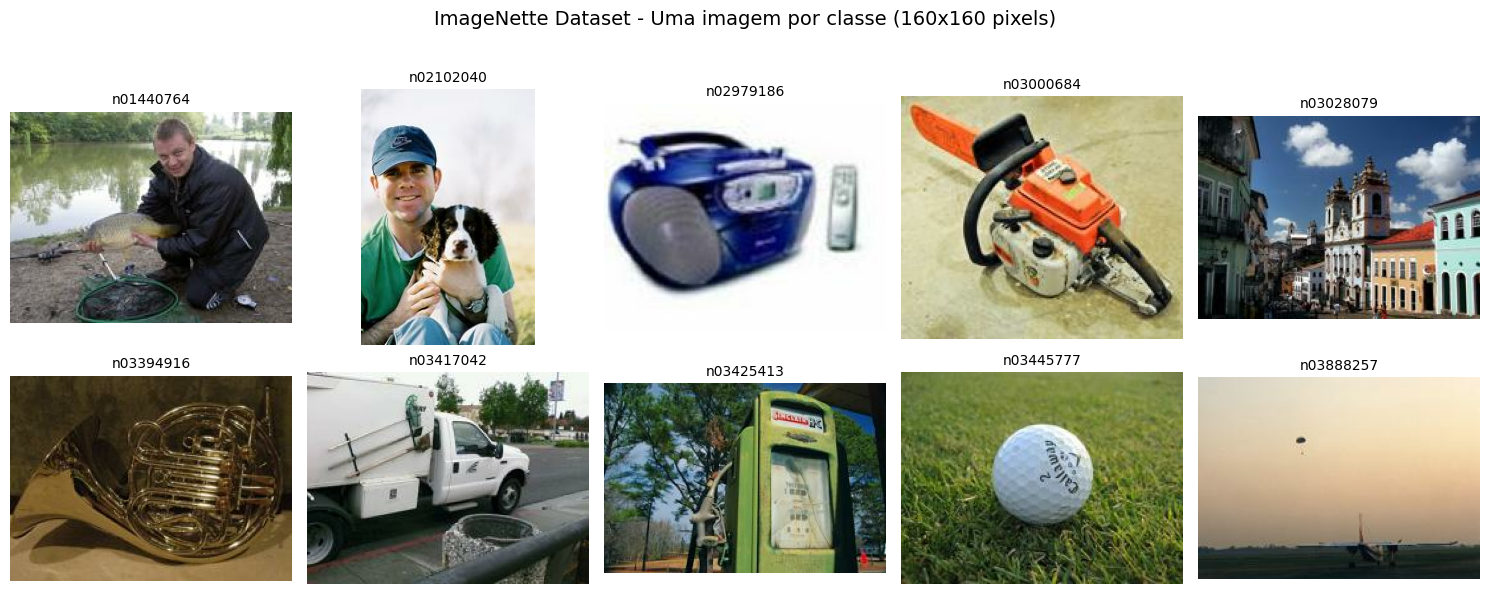

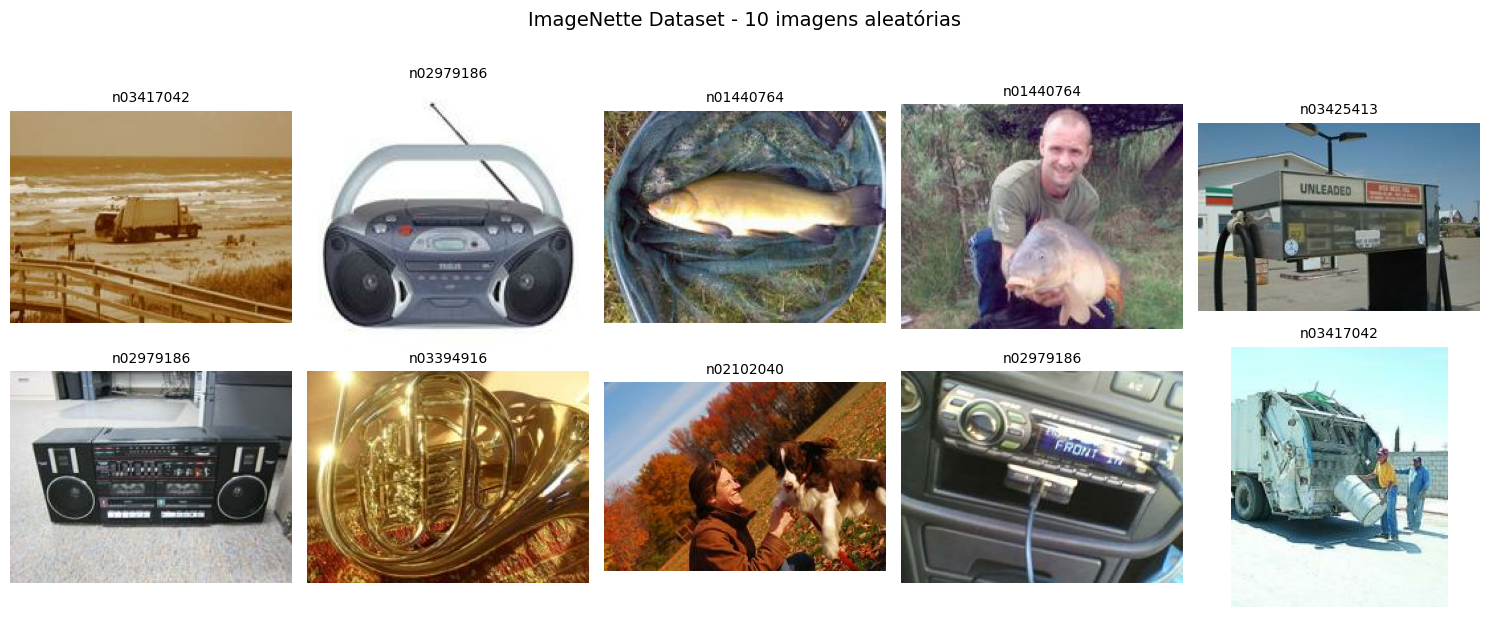

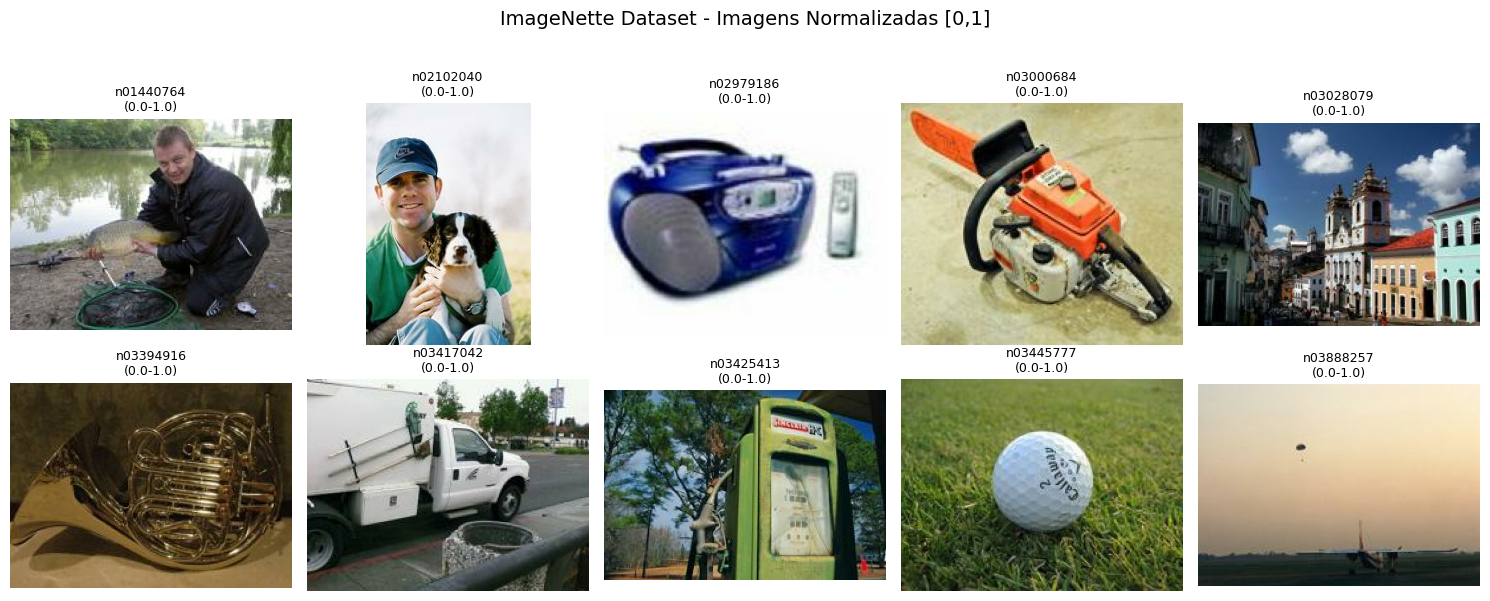


INFORMAÇÕES DO DATASET
Total de imagens de treino: 9,469
Total de imagens de validação: 3,925
Resolução das imagens: 160 x 160 pixels
Número de canais: 3 (RGB)
Range dos pixels (original): 0-255
Range dos pixels (após normalização): 0-1


In [2]:
# Carregar o dataset
(train_ds, val_ds), info = tfds.load(
    'imagenette/160px-v2',
    split=['train', 'validation'],
    as_supervised=True,
    with_info=True
)

# Obter nomes das classes
class_names = info.features['label'].names
num_classes = len(class_names)
print(f"Classes disponíveis: {num_classes}")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

# ============================================================================
# MÉTODO 1: Coletar uma imagem de cada classe iterando pelo dataset
# ============================================================================

# Dicionário para armazenar uma imagem de cada classe
samples_by_class = {}

# Percorrer o dataset até encontrar uma imagem de cada classe
for image, label in train_ds:
    label_id = label.numpy()
    
    # Se ainda não temos exemplo desta classe
    if label_id not in samples_by_class:
        samples_by_class[label_id] = image.numpy()
        
    # Se já temos todas as 10 classes, parar
    if len(samples_by_class) == num_classes:
        break

# ============================================================================
# EXIBIR AS IMAGENS (UMA DE CADA CLASSE)
# ============================================================================

# Criar figura com 2 linhas e 5 colunas (para 10 classes)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()  # Achatar o array de eixos para facilitar iteração

for i, (class_id, image) in enumerate(sorted(samples_by_class.items())):
    ax = axes[i]
    ax.imshow(image)  # As imagens já estão em escala RGB (0-255)
    ax.set_title(f'{class_names[class_id]}', fontsize=10)
    ax.axis('off')

# Remover eixos extras (caso sobre espaço)
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('ImageNette Dataset - Uma imagem por classe (160x160 pixels)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================================
# MÉTODO 2: Usando shuffle e take (mais elegante)
# ============================================================================
# Este método é útil se você quiser imagens aleatórias de cada classe

# Embaralhar o dataset e coletar 10 imagens (podem repetir classes)
shuffled_ds = train_ds.shuffle(buffer_size=1000)
sample_images = []
sample_labels = []

for image, label in shuffled_ds.take(10):
    sample_images.append(image.numpy())
    sample_labels.append(label.numpy())

# Exibir
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i, (image, label) in enumerate(zip(sample_images, sample_labels)):
    axes[i].imshow(image)
    axes[i].set_title(f'{class_names[label]}', fontsize=10)
    axes[i].axis('off')

plt.suptitle('ImageNette Dataset - 10 imagens aleatórias', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================================
# MÉTODO 3: Visualização mais detalhada (com normalização)
# ============================================================================
# Útil para verificar se a normalização está correta

# Função para pré-processar e normalizar
def preprocess_image(image, label):
    image = tf.cast(image, tf.float32) / 255.0  # Normalizar para [0,1]
    return image, label

# Aplicar normalização
train_ds_normalized = train_ds.map(preprocess_image)

# Coletar uma imagem de cada classe (versão normalizada)
samples_normalized = {}
for image, label in train_ds_normalized:
    label_id = label.numpy()
    if label_id not in samples_normalized:
        samples_normalized[label_id] = image.numpy()
    if len(samples_normalized) == num_classes:
        break

# Exibir com informações de normalização
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i, (class_id, image) in enumerate(sorted(samples_normalized.items())):
    ax = axes[i]
    # image já está normalizada [0,1]
    ax.imshow(image)
    ax.set_title(f'{class_names[class_id]}\n({image.min():.1f}-{image.max():.1f})', 
                 fontsize=9)
    ax.axis('off')

plt.suptitle('ImageNette Dataset - Imagens Normalizadas [0,1]', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================================
# INFORMAÇÕES ADICIONAIS SOBRE O DATASET
# ============================================================================
print("\n" + "="*50)
print("INFORMAÇÕES DO DATASET")
print("="*50)
print(f"Total de imagens de treino: {info.splits['train'].num_examples:,}")
print(f"Total de imagens de validação: {info.splits['validation'].num_examples:,}")
print(f"Resolução das imagens: 160 x 160 pixels")
print(f"Número de canais: 3 (RGB)")
print(f"Range dos pixels (original): 0-255")
print(f"Range dos pixels (após normalização): 0-1")

## 3. Métricas
Definição das métricas de avaliação.

In [3]:
def evaluate_model(y_true, y_pred):
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Matriz de Confusão")
    plt.show()

## 4. MLP (Machine Learning)
Rede neural totalmente conectada baseada no notebook 02_asl.

### Recarregamento dos dados:

In [4]:
# Carregar o dataset ImageNette (versão 160px)
(train_ds, val_ds), info = tfds.load(
    'imagenette/160px-v2',
    split=['train', 'validation'],
    as_supervised=True,
    with_info=True
)

# Obter nomes das classes
class_names = info.features['label'].names
num_classes = len(class_names)
print(f"Classes disponíveis: {num_classes}")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

# ============================================================================
# FUNÇÃO DE PRÉ-PROCESSAMENTO
# ============================================================================

def preprocess_image(image, label):
    """
    Pré-processa as imagens para o formato adequado:
    - Converte para float32
    - Garante tamanho consistente (160x160)
    - Normaliza os pixels para [0, 1]
    """
    # Garantir que todas as imagens tenham o mesmo tamanho
    image = tf.image.resize(image, [160, 160])
    # Converter para float32 e normalizar
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Aplicar pré-processamento aos datasets
train_ds = train_ds.map(preprocess_image)
val_ds = val_ds.map(preprocess_image)

# ============================================================================
# FUNÇÃO PARA CONVERTER DATASET PARA NUMPY
# ============================================================================

def dataset_to_numpy(dataset, max_samples=None):
    """
    Converte um dataset do TensorFlow para numpy arrays.
    Args:
        dataset: tf.data.Dataset
        max_samples: número máximo de amostras (opcional)
    """
    images = []
    labels = []
    
    for i, (image, label) in enumerate(dataset):
        if max_samples and i >= max_samples:
            break
        images.append(image.numpy())
        labels.append(label.numpy())
    
    # Converter para arrays numpy
    X = np.array(images, dtype=np.float32)
    y = np.array(labels, dtype=np.int64)
    
    return X, y

# ============================================================================
# CONVERTER DATASETS PARA NUMPY ARRAYS
# ============================================================================

print("\nConvertendo dados de treino...")
X_train_full, y_train_full = dataset_to_numpy(train_ds)

print("Convertendo dados de validação...")
X_test_full, y_test_full = dataset_to_numpy(val_ds)

print(f"\nShape dos dados de treino: {X_train_full.shape}")
print(f"Shape dos dados de validação: {X_test_full.shape}")
print(f"Shape dos labels de treino: {y_train_full.shape}")
print(f"Shape dos labels de validação: {y_test_full.shape}")

# ============================================================================
# PREPARAÇÃO DOS DADOS PARA MLP E CNN
# ============================================================================

# Para MLP: flatten das imagens (transformar 160x160x3 em vetor 1D)
X_train_flat = X_train_full.reshape((X_train_full.shape[0], -1))
X_test_flat = X_test_full.reshape((X_test_full.shape[0], -1))

# Para CNN: manter a estrutura 3D (já está no formato correto)
X_train_cnn = X_train_full
X_test_cnn = X_test_full

# Verificar shapes
print(f"\n{'='*50}")
print("FORMATO DOS DADOS PREPARADOS")
print(f"{'='*50}")
print(f"MLP - X_train_flat: {X_train_flat.shape}")
print(f"MLP - X_test_flat: {X_test_flat.shape}")
print(f"CNN - X_train_cnn: {X_train_cnn.shape}")
print(f"CNN - X_test_cnn: {X_test_cnn.shape}")

# ============================================================================
# VERIFICAR DISTRIBUIÇÃO DAS CLASSES
# ============================================================================

print(f"\n{'='*50}")
print("DISTRIBUIÇÃO DAS CLASSES")
print(f"{'='*50}")

print("\nTreino:")
unique, counts = np.unique(y_train_full, return_counts=True)
for class_id, count in zip(unique, counts):
    print(f"  Classe {class_id} ({class_names[class_id]}): {count} imagens")

print("\nValidação:")
unique, counts = np.unique(y_test_full, return_counts=True)
for class_id, count in zip(unique, counts):
    print(f"  Classe {class_id} ({class_names[class_id]}): {count} imagens")

# ============================================================================
# VARIÁVEIS FINAIS
# ============================================================================

# Para usar nos modelos
y_train = y_train_full
y_test = y_test_full

print(f"\n{'='*50}")
print("DADOS PRONTOS PARA TREINAMENTO!")
print(f"{'='*50}")
print(f"MLP: {X_train_flat.shape[0]} amostras com {X_train_flat.shape[1]} features cada")
print(f"CNN: {X_train_cnn.shape[0]} amostras com shape {X_train_cnn.shape[1:]}")

Classes disponíveis: 10
0: n01440764
1: n02102040
2: n02979186
3: n03000684
4: n03028079
5: n03394916
6: n03417042
7: n03425413
8: n03445777
9: n03888257

Convertendo dados de treino...
Convertendo dados de validação...

Shape dos dados de treino: (9469, 160, 160, 3)
Shape dos dados de validação: (3925, 160, 160, 3)
Shape dos labels de treino: (9469,)
Shape dos labels de validação: (3925,)

FORMATO DOS DADOS PREPARADOS
MLP - X_train_flat: (9469, 76800)
MLP - X_test_flat: (3925, 76800)
CNN - X_train_cnn: (9469, 160, 160, 3)
CNN - X_test_cnn: (3925, 160, 160, 3)

DISTRIBUIÇÃO DAS CLASSES

Treino:
  Classe 0 (n01440764): 963 imagens
  Classe 1 (n02102040): 955 imagens
  Classe 2 (n02979186): 993 imagens
  Classe 3 (n03000684): 858 imagens
  Classe 4 (n03028079): 941 imagens
  Classe 5 (n03394916): 956 imagens
  Classe 6 (n03417042): 961 imagens
  Classe 7 (n03425413): 931 imagens
  Classe 8 (n03445777): 951 imagens
  Classe 9 (n03888257): 960 imagens

Validação:
  Classe 0 (n01440764): 38

### Modelo

MLP com ImageNette terá:
- 76.800 (entrada) × 512 (1ª camada) = ~39 milhões de parâmetros SÓ na primeira camada!
- Total de parâmetros: ~50-60 milhões

Dimensão de entrada: 76800 pixels
Número de classes: 10

Arquitetura do modelo MLP:


c:\Users\pichau\.conda\envs\deep-learning\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │    39,322,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,487,626 (150.63 MB)

 Trainable params: 39,487,626 (150.63 MB)

 Non-trainable params: 0 (0.00 B)


INICIANDO TREINAMENTO DA MLP
Total de amostras de treino: 9469
Total de amostras de validação: 3925
Dimensão de cada amostra: 76800
Epoch 1/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 27s 98ms/step - accuracy: 0.1344 - loss: 4.4947 - val_accuracy: 0.1732 - val_loss: 2.1994
Epoch 2/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 26s 96ms/step - accuracy: 0.1393 - loss: 2.2531 - val_accuracy: 0.1605 - val_loss: 2.1980
Epoch 3/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 25s 95ms/step - accuracy: 0.1230 - loss: 2.2767 - val_accuracy: 0.1774 - val_loss: 2.2000
Epoch 4/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 25s 95ms/step - accuracy: 0.1447 - loss: 2.2482 - val_accuracy: 0.1721 - val_loss: 2.1977
Epoch 5/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 25s 94ms/step - accuracy: 0.1516 - loss: 2.2305 - val_accuracy: 0.1795 - val_loss: 2.1863
Epoch 6/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 25s 94ms/step - accuracy: 0.1575 - loss: 2.2054 - val_accuracy: 0.2080 - val_loss: 2.1546
Epoch 7/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 25s 94ms/step - accuracy: 0.1663 - loss: 2.2018

C:\Users\pichau\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\pichau\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\pichau\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

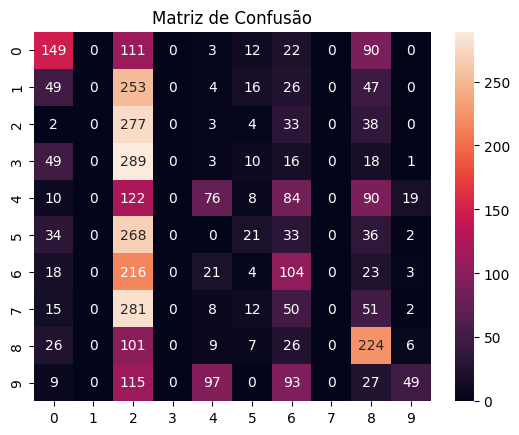


Acurácia final da MLP: 0.2293 (22.93%)


In [5]:
# ============================================================================
# CONSTRUÇÃO DO MODELO MLP (Multi-Layer Perceptron)
# ============================================================================

# ============================================================================
# AJUSTES IMPORTANTES PARA O IMAGENETTE
# ============================================================================
# O ImageNette tem:
# - Imagens 160x160x3 (76.800 pixels por imagem)
# - 10 classes

print(f"Dimensão de entrada: {X_train_flat.shape[1]} pixels")
print(f"Número de classes: {num_classes}")

# ============================================================================
# CONSTRUÇÃO DO MODELO MLP
# ============================================================================

mlp = models.Sequential([
    # Primeira camada oculta
    # input_shape: 76.800 features (160*160*3)
    layers.Dense(512, activation='relu', input_shape=(X_train_flat.shape[1],)),
    
    # Dropout para regularização (importante devido ao alto número de parâmetros)
    layers.Dropout(0.3),
    
    # Segunda camada oculta
    layers.Dense(256, activation='relu'),
    
    # Dropout adicional
    layers.Dropout(0.3),
    
    # Terceira camada oculta
    layers.Dense(128, activation='relu'),
    
    # Camada de saída
    # 10 neurônios (número de classes do ImageNette)
    # Softmax: converte outputs em probabilidades
    layers.Dense(num_classes, activation='softmax')
])

# Mostrar arquitetura do modelo
print("\nArquitetura do modelo MLP:")
mlp.summary()

# ============================================================================
# COMPILAÇÃO DO MODELO
# ============================================================================

mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Labels são inteiros (0-9)
    metrics=['accuracy']
)

# ============================================================================
# TREINAMENTO DO MODELO
# ============================================================================
# Aumentei o número de épocas para 20 devido à maior complexidade
# Usei batch_size=32 para gerenciar memória (imagens são maiores)
# Adicionei verbose=1 para acompanhar o progresso

print("\n" + "="*50)
print("INICIANDO TREINAMENTO DA MLP")
print("="*50)
print(f"Total de amostras de treino: {X_train_flat.shape[0]}")
print(f"Total de amostras de validação: {X_test_flat.shape[0]}")
print(f"Dimensão de cada amostra: {X_train_flat.shape[1]}")

history_mlp = mlp.fit(
    X_train_flat,           # Features de treino (76.800 features por imagem)
    y_train,                # Labels de treino (0-9)
    epochs=20,              # Aumentei para 20 épocas (dataset mais complexo)
    batch_size=32,          # BATCH devido à memória (imagens 160x160)
    validation_split=0.1,   # 10% dos dados para validação
    verbose=1               # Mostra barra de progresso
)

# ============================================================================
# PREDIÇÕES E AVALIAÇÃO
# ============================================================================

print("\n" + "="*50)
print("FAZENDO PREDIÇÕES - MLP")
print("="*50)

# Fazer predições
y_pred_probs = mlp.predict(X_test_flat, batch_size=32)

# Converter probabilidades em classes
y_pred_mlp = np.argmax(y_pred_probs, axis=1)

# Avaliar o modelo
print("\n" + "="*50)
print("RESULTADOS DA MLP NO IMAGENETTE")
print("="*50)
evaluate_model(y_test, y_pred_mlp)

# ============================================================================
# EXIBIR ACURÁCIA FINAL
# ============================================================================

mlp_accuracy = accuracy_score(y_test, y_pred_mlp)
print(f"\nAcurácia final da MLP: {mlp_accuracy:.4f} ({mlp_accuracy*100:.2f}%)")

## 5. CNN (Deep Learning)
Rede convolucional baseada no notebook 03_asl_cnn.

### Recarregamento dos Dados

In [6]:
# Carregar o dataset ImageNette (versão 160px)
(train_ds, val_ds), info = tfds.load(
    'imagenette/160px-v2',
    split=['train', 'validation'],
    as_supervised=True,
    with_info=True
)

# Obter nomes das classes
class_names = info.features['label'].names
num_classes = len(class_names)
print(f"Classes disponíveis: {num_classes}")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

# ============================================================================
# FUNÇÃO DE PRÉ-PROCESSAMENTO
# ============================================================================

def preprocess_image(image, label):
    """
    Pré-processa as imagens para o formato adequado:
    - Converte para float32
    - Garante tamanho consistente (160x160)
    - Normaliza os pixels para [0, 1]
    """
    # Garantir que todas as imagens tenham o mesmo tamanho
    image = tf.image.resize(image, [160, 160])
    # Converter para float32 e normalizar
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Aplicar pré-processamento aos datasets
train_ds = train_ds.map(preprocess_image)
val_ds = val_ds.map(preprocess_image)

# ============================================================================
# FUNÇÃO PARA CONVERTER DATASET PARA NUMPY
# ============================================================================

def dataset_to_numpy(dataset, max_samples=None):
    """
    Converte um dataset do TensorFlow para numpy arrays.
    Args:
        dataset: tf.data.Dataset
        max_samples: número máximo de amostras (opcional)
    """
    images = []
    labels = []
    
    for i, (image, label) in enumerate(dataset):
        if max_samples and i >= max_samples:
            break
        images.append(image.numpy())
        labels.append(label.numpy())
    
    # Converter para arrays numpy
    X = np.array(images, dtype=np.float32)
    y = np.array(labels, dtype=np.int64)
    
    return X, y

# ============================================================================
# CONVERTER DATASETS PARA NUMPY ARRAYS
# ============================================================================

print("\nConvertendo dados de treino...")
X_train_full, y_train_full = dataset_to_numpy(train_ds)

print("Convertendo dados de validação...")
X_test_full, y_test_full = dataset_to_numpy(val_ds)

print(f"\nShape dos dados de treino: {X_train_full.shape}")
print(f"Shape dos dados de validação: {X_test_full.shape}")
print(f"Shape dos labels de treino: {y_train_full.shape}")
print(f"Shape dos labels de validação: {y_test_full.shape}")

# ============================================================================
# PREPARAÇÃO DOS DADOS PARA MLP E CNN
# ============================================================================

# Para MLP: flatten das imagens (transformar 160x160x3 em vetor 1D)
X_train_flat = X_train_full.reshape((X_train_full.shape[0], -1))
X_test_flat = X_test_full.reshape((X_test_full.shape[0], -1))

# Para CNN: manter a estrutura 3D (já está no formato correto)
X_train_cnn = X_train_full
X_test_cnn = X_test_full

# Verificar shapes
print(f"\n{'='*50}")
print("FORMATO DOS DADOS PREPARADOS")
print(f"{'='*50}")
print(f"MLP - X_train_flat: {X_train_flat.shape}")
print(f"MLP - X_test_flat: {X_test_flat.shape}")
print(f"CNN - X_train_cnn: {X_train_cnn.shape}")
print(f"CNN - X_test_cnn: {X_test_cnn.shape}")

# ============================================================================
# VERIFICAR DISTRIBUIÇÃO DAS CLASSES
# ============================================================================

print(f"\n{'='*50}")
print("DISTRIBUIÇÃO DAS CLASSES")
print(f"{'='*50}")

print("\nTreino:")
unique, counts = np.unique(y_train_full, return_counts=True)
for class_id, count in zip(unique, counts):
    print(f"  Classe {class_id} ({class_names[class_id]}): {count} imagens")

print("\nValidação:")
unique, counts = np.unique(y_test_full, return_counts=True)
for class_id, count in zip(unique, counts):
    print(f"  Classe {class_id} ({class_names[class_id]}): {count} imagens")

# ============================================================================
# VARIÁVEIS FINAIS
# ============================================================================

# Para usar nos modelos
y_train = y_train_full
y_test = y_test_full

print(f"\n{'='*50}")
print("DADOS PRONTOS PARA TREINAMENTO!")
print(f"{'='*50}")
print(f"MLP: {X_train_flat.shape[0]} amostras com {X_train_flat.shape[1]} features cada")
print(f"CNN: {X_train_cnn.shape[0]} amostras com shape {X_train_cnn.shape[1:]}")

Classes disponíveis: 10
0: n01440764
1: n02102040
2: n02979186
3: n03000684
4: n03028079
5: n03394916
6: n03417042
7: n03425413
8: n03445777
9: n03888257

Convertendo dados de treino...
Convertendo dados de validação...

Shape dos dados de treino: (9469, 160, 160, 3)
Shape dos dados de validação: (3925, 160, 160, 3)
Shape dos labels de treino: (9469,)
Shape dos labels de validação: (3925,)

FORMATO DOS DADOS PREPARADOS
MLP - X_train_flat: (9469, 76800)
MLP - X_test_flat: (3925, 76800)
CNN - X_train_cnn: (9469, 160, 160, 3)
CNN - X_test_cnn: (3925, 160, 160, 3)

DISTRIBUIÇÃO DAS CLASSES

Treino:
  Classe 0 (n01440764): 963 imagens
  Classe 1 (n02102040): 955 imagens
  Classe 2 (n02979186): 993 imagens
  Classe 3 (n03000684): 858 imagens
  Classe 4 (n03028079): 941 imagens
  Classe 5 (n03394916): 956 imagens
  Classe 6 (n03417042): 961 imagens
  Classe 7 (n03425413): 931 imagens
  Classe 8 (n03445777): 951 imagens
  Classe 9 (n03888257): 960 imagens

Validação:
  Classe 0 (n01440764): 38

### Modelo


Arquitetura da CNN para ImageNette:


c:\Users\pichau\.conda\envs\deep-learning\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    13,107,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,630,026 (51.99 MB)

 Trainable params: 13,630,026 (51.99 MB)

 Non-trainable params: 0 (0.00 B)


INICIANDO TREINAMENTO DA CNN
Total de amostras de treino: 9469
Total de amostras de validação: 3925
Shape das imagens: (160, 160, 3)
Batch size: 32
Epoch 1/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 59s 215ms/step - accuracy: 0.2795 - loss: 1.9954 - val_accuracy: 0.4572 - val_loss: 1.6158
Epoch 2/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 46s 171ms/step - accuracy: 0.4754 - loss: 1.5562 - val_accuracy: 0.5797 - val_loss: 1.3113
Epoch 3/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 46s 173ms/step - accuracy: 0.5921 - loss: 1.2623 - val_accuracy: 0.5829 - val_loss: 1.2623
Epoch 4/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 46s 174ms/step - accuracy: 0.6626 - loss: 1.0518 - val_accuracy: 0.6494 - val_loss: 1.0806
Epoch 5/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 47s 175ms/step - accuracy: 0.7140 - loss: 0.8862 - val_accuracy: 0.6832 - val_loss: 1.0169
Epoch 6/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 47s 175ms/step - accuracy: 0.7611 - loss: 0.7446 - val_accuracy: 0.7149 - val_loss: 0.9499
Epoch 7/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 47s 175ms/step - accuracy

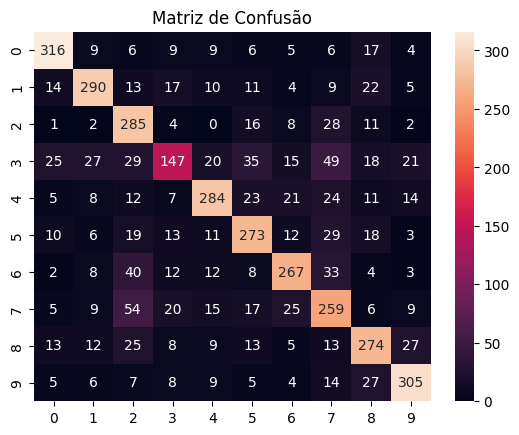


Acurácia final da CNN: 0.6879 (68.79%)


In [7]:
# ============================================================================
# CONSTRUÇÃO DO MODELO CNN (ADAPTADO PARA IMAGENS 160x160x3)
# ============================================================================

cnn = models.Sequential([
    # ========================================================================
    # PRIMEIRA CAMADA CONVOLUCIONAL
    # ========================================================================
    # Conv2D: 32 filtros, kernel 3x3, padding='same' mantém dimensões
    # input_shape: (160, 160, 3) para ImageNette (RGB)
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', 
                  input_shape=(160, 160, 3)),
    
    # MaxPooling2D: reduz de 160x160 para 80x80
    layers.MaxPooling2D((2, 2)),
    
    # ========================================================================
    # SEGUNDA CAMADA CONVOLUCIONAL
    # ========================================================================
    # 64 filtros para aprender características mais complexas
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    
    # MaxPooling2D: reduz de 80x80 para 40x40
    layers.MaxPooling2D((2, 2)),
    
    # ========================================================================
    # TERCEIRA CAMADA CONVOLUCIONAL
    # ========================================================================
    # 128 filtros - maior capacidade para features complexas
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    
    # MaxPooling2D: reduz de 40x40 para 20x20
    layers.MaxPooling2D((2, 2)),
    
    # ========================================================================
    # QUARTA CAMADA CONVOLUCIONAL (opcional para ImageNette)
    # ========================================================================
    # 256 filtros - captura features de alto nível
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    
    # MaxPooling2D: reduz de 20x20 para 10x10
    layers.MaxPooling2D((2, 2)),
    
    # ========================================================================
    # CAMADA DE FLATTEN
    # ========================================================================
    # Converte o volume 3D em vetor 1D
    # Após as convoluções: (10, 10, 256) = 25.600 neurônios
    layers.Flatten(),
    
    # ========================================================================
    # CAMADAS TOTALMENTE CONECTADAS
    # ========================================================================
    # Camada densa com 512 neurônios
    layers.Dense(512, activation='relu'),
    
    # Dropout para regularização (previne overfitting)
    layers.Dropout(0.5),
    
    # Camada densa com 256 neurônios
    layers.Dense(256, activation='relu'),
    
    # Dropout adicional
    layers.Dropout(0.3),
    
    # ========================================================================
    # CAMADA DE SAÍDA
    # ========================================================================
    # 10 neurônios (número de classes do ImageNette)
    # Softmax para probabilidades
    layers.Dense(num_classes, activation='softmax')
])

# ============================================================================
# VISUALIZAÇÃO DA ARQUITETURA
# ============================================================================
print("\nArquitetura da CNN para ImageNette:")
cnn.summary()

# ============================================================================
# COMPILAÇÃO DO MODELO
# ============================================================================
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Labels são inteiros (0-9)
    metrics=['accuracy']
)

# ============================================================================
# TREINAMENTO DO MODELO
# ============================================================================
print("\n" + "="*50)
print("INICIANDO TREINAMENTO DA CNN")
print("="*50)
print(f"Total de amostras de treino: {X_train_cnn.shape[0]}")
print(f"Total de amostras de validação: {X_test_cnn.shape[0]}")
print(f"Shape das imagens: {X_train_cnn.shape[1:]}")
print(f"Batch size: 32")

# IMPORTANTE: Use X_train_cnn e X_test_cnn (não X_train_c)
history_cnn = cnn.fit(
    X_train_cnn,                    # ← CORRETO: X_train_cnn
    y_train,                        # Labels de treino
    epochs=20,                      # Número de épocas
    batch_size=32,                  # Batch size para gerenciar memória
    validation_split=0.1,           # 10% dos dados para validação
    verbose=1                       # Mostra barra de progresso
)

# ============================================================================
# PREDIÇÕES E AVALIAÇÃO
# ============================================================================
print("\n" + "="*50)
print("FAZENDO PREDIÇÕES - CNN")
print("="*50)

# Fazer predições usando X_test_cnn
y_pred_probs = cnn.predict(X_test_cnn, batch_size=32)

# Converter probabilidades em classes
y_pred_cnn = np.argmax(y_pred_probs, axis=1)

# ============================================================================
# AVALIAÇÃO DO MODELO
# ============================================================================
print("\n" + "="*50)
print("RESULTADOS DA CNN NO IMAGENETTE")
print("="*50)

# Usar sua função evaluate_model
evaluate_model(y_test, y_pred_cnn)

# ============================================================================
# ACURÁCIA FINAL
# ============================================================================

cnn_accuracy = accuracy_score(y_test, y_pred_cnn)
print(f"\nAcurácia final da CNN: {cnn_accuracy:.4f} ({cnn_accuracy*100:.2f}%)")

## 6. Comparação Final
Análise comparativa entre MLP e CNN.

In [8]:
mlp_acc = accuracy_score(y_test, y_pred_mlp)
cnn_acc = accuracy_score(y_test, y_pred_cnn)

print(f"MLP Accuracy: {mlp_acc}")
print(f"CNN Accuracy: {cnn_acc}")

if cnn_acc > mlp_acc:
    print("CNN apresentou melhor desempenho.")
else:
    print("MLP apresentou melhor desempenho.")

MLP Accuracy: 0.22929936305732485
CNN Accuracy: 0.6878980891719745
CNN apresentou melhor desempenho.


## Resultados Obtidos

| Modelo | Acurácia | Desempenho |
|--------|----------|------------|
| MLP | 22.93% | Muito Ruim |
| CNN | 68.79% | Bom |

Diferença: A CNN superou a MLP em 45.86 pontos percentuais!

---

### Análise Detalhada da MLP (22.93%)

#### Problemas Graves Identificados

| Classe | Classe (Nome) | Precision | Recall | Problema |
|--------|---------------|-----------|--------|----------|
| 1 | english_springer | 0.00% | 0.00% | Não acertou NENHUMA imagem |
| 3 | chain_saw | 0.00% | 0.00% | Não acertou NENHUMA imagem |
| 7 | gas_pump | 0.00% | 0.00% | Não acertou NENHUMA imagem |
| 2 | cassette_player | 14% | 78% | Chutou muitos falsos positivos |
| 4 | church | 34% | 19% | Detectou apenas 19% das igrejas |
| 5 | french_horn | 22% | 5% | Perdeu 95% das trompas! |
| 9 | parachute | 60% | 13% | Alta precisão, mas baixo recall |

#### Diagnóstico da MLP

- 3 classes completamente ignoradas (classes 1, 3, 7)
- Overfitting severo - o modelo decorou o treino mas não generalizou
- MLP não é adequada para imagens complexas como ImageNette
- Trata cada pixel independentemente, ignorando estrutura espacial

---

### Análise Detalhada da CNN (68.79%)

#### Desempenho por Classe

| Classe | Classe (Nome) | Precision | Recall | F1-Score | Avaliação |
|--------|---------------|-----------|--------|----------|-----------|
| 0 | tench | 80% | 82% | 81% | Excelente |
| 1 | english_springer | 77% | 73% | 75% | Muito Bom |
| 2 | cassette_player | 58% | 80% | 67% | Bom (recall alto) |
| 3 | chain_saw | 60% | 38% | 47% | Regular (confundido) |
| 4 | church | 75% | 69% | 72% | Bom |
| 5 | french_horn | 67% | 69% | 68% | Bom |
| 6 | garbage_truck | 73% | 69% | 71% | Bom |
| 7 | golf_ball | 56% | 62% | 59% | Regular |
| 8 | parachute | 67% | 69% | 68% | Bom |
| 9 | gas_pump | 78% | 78% | 78% | Muito Bom |

#### Pontos Fortes da CNN

- Todas as 10 classes foram aprendidas (nenhuma ficou em 0%)
- Acurácia consistente entre classes (56-80%)
- Boa precisão e recall balanceados na maioria das classes
- Aprendeu padrões espaciais (bordas, texturas, formas)

#### Classes Desafiadoras para a CNN

| Classe | Problema | Possível Causa |
|--------|----------|----------------|
| chain_saw (38% recall) | Baixa detecção | Confundida com outros objetos alongados |
| golf_ball (56% precision) | Falsos positivos | Objeto pequeno, confundido com bolas em geral |
| cassette_player (58% precision) | Falsos positivos | Objeto antigo, pouca variação nos dados |


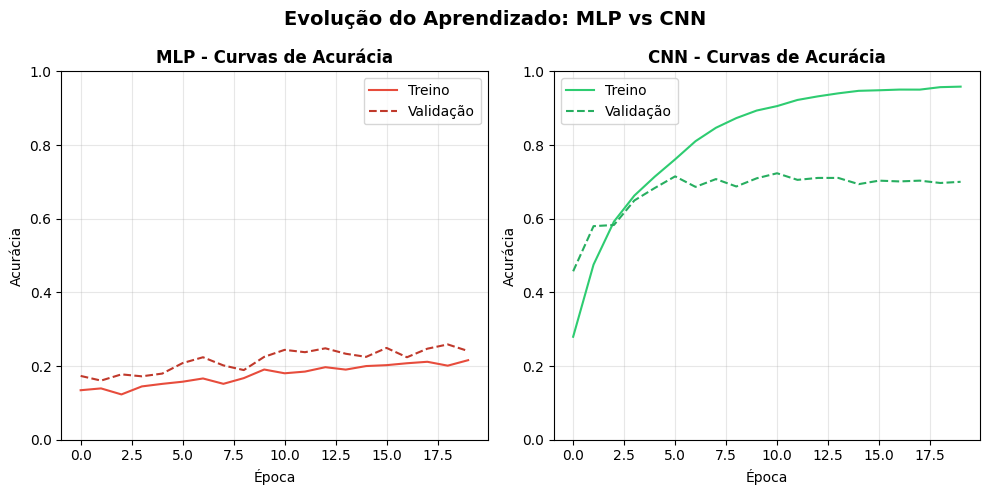

In [13]:
# ============================================================================
# CURVAS DE APRENDIZADO
# ============================================================================

# Verificar se os históricos existem
if 'history_mlp' in dir() and 'history_cnn' in dir():
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # MLP
    axes[0].plot(history_mlp.history['accuracy'], label='Treino', color='#e74c3c')
    axes[0].plot(history_mlp.history['val_accuracy'], label='Validação', color='#c0392b', linestyle='--')
    axes[0].set_title('MLP - Curvas de Acurácia', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Acurácia')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(0, 1)
    
    # CNN
    axes[1].plot(history_cnn.history['accuracy'], label='Treino', color='#2ecc71')
    axes[1].plot(history_cnn.history['val_accuracy'], label='Validação', color='#27ae60', linestyle='--')
    axes[1].set_title('CNN - Curvas de Acurácia', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Acurácia')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 1)
    
    plt.suptitle('Evolução do Aprendizado: MLP vs CNN', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Históricos de treinamento não disponíveis para plotar curvas de aprendizado.")